# BurbankBus Ridership Modeling: Analytical Summary and Interpretation

1. Load Stop-Level Data
2. Prepare Data for Negative Binomial Regression
- Create a log-transformed variable for arrivals: log_arrivals = log(n_arrivals + 1)
- Select explanatory variables: number of routes, arrivals, population-adjusted measures.
3.  Get Stop-Level Data for Existing Operators
- Query GTFS scheduled stop data across Burbank, Metro, and Metrolink
- Load new stop lists for Orange and Blue route changes.
4. Assign Missing Coordinates for New Stops
5. Spatial Buffering and ACS Demographic Overlays
- Convert new stops to UTM projection, buffer, overlay census tract and compute proportional demographic counts using area ratios
6. Match New Stops to Nearest Existing Stops
- Inherit baseline n_routes and daily_arrivals where applicable.
7. Construct Baseline and Scenario Service Variables
- New stops assigned 1 route in scenario, 0 in baseline.
- Scenario arrivals set to baseline arrivals + 51 additional trips.
8. Generate Prediction Inputs
- Create scenario (X_scn) and baseline (X_base) covariate matrices.
9. Predict Ridership Effects
- Apply fitted NB model to scenario and baseline inputs.
- Compute predicted ridership change as: pred_scenario - pred_baseline
- Sum stop-level changes to obtain systemwide change











  






In [1]:
pip install shared_utils

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing necessary package 
import pandas as pd 
import geopandas as gpd
pd.set_option('display.max_columns', None)
import os
import google.auth
import gcsfs
fs = gcsfs.GCSFileSystem()
import statsmodels.api as sm
import numpy as np
from scipy.stats import skew
from calitp_data_analysis.sql import get_engine
db_engine = get_engine()
credentials, project = google.auth.default()
fs = gcsfs.GCSFileSystem()
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
GCS_FILE_PATH = 'gs://calitp-analytics-data/data-analyses/ahsc_grant/ahsc_riderships/AHSC_2026'
with fs.open(f"{GCS_FILE_PATH}/stop_route_df.parquet", "rb") as f: 
    stop_route_df = gpd.read_parquet(f)

In [4]:
stop_route_df.columns

Index(['organization_name', 'feed_key', 'stop_id', 'stop_name', 'stop_code',
       'n_arrivals', 'n_routes', 'pt_geom', 'day_type',
       'average_daily_boardings', 'average_daily_alightings', 'start_date',
       'end_date', 'geometry', 'total_pop_adj', 'poverty_pop_adj',
       'non_us_citizen_adj', 'workers_with_no_car_adj',
       'households_with_no_cars_adj', 'disabled_pop_adj',
       'public_asst_pop_adj', 'inc_extremelylow_adj', 'inc_verylow_adj',
       'inc_low_adj', 'male_seniors_adj', 'female_seniors_adj',
       'veteran_pop_adj', 'male_youth_adj', 'inc_total_lowincome_adj',
       'female_youth_adj', 'total_seniors_adj', 'jobs_tot_adj',
       'total_youth_adj', 'ALAND_adj'],
      dtype='object')

In [5]:
# Convert n_arrivals and n_routes to integer
stop_route_df['n_arrivals'] = stop_route_df['n_arrivals'].fillna(0).astype(int)
stop_route_df['n_routes'] = stop_route_df['n_routes'].fillna(0).astype(int)

In [6]:
# Copy the dataset
df = stop_route_df.copy()
y = df['average_daily_boardings']
df["log_arrivals"] = np.log(df["n_arrivals"] + 1)
X = df[['n_routes', 'log_arrivals',
        'total_pop_adj', 'workers_with_no_car_adj',  'total_youth_adj', 'public_asst_pop_adj', 'total_seniors_adj', "inc_total_lowincome_adj",]]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended.summary())

/opt/conda/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                21264
Model:                                 GLM   Df Residuals:                    21255
Model Family:             NegativeBinomial   Df Model:                            8
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -82687.
Date:                     Thu, 30 Apr 2026   Deviance:                       38057.
Time:                             18:39:00   Pearson chi2:                 2.81e+05
No. Iterations:                         54   Pseudo R-squ. (CS):             0.8323
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

adding a route while holding arrivals constant reduces ridership per stop

- New Blue Route	n_routes +1
- Extended Orange Route	n_routes +1 (partial effect)
- More service / frequency	n_arrivals ↑
- Weekend service	: currently this model is just weekday model
- New stops	new rows (or modified features)

In [7]:
df_burbank = stop_route_df[stop_route_df['organization_name'] == "City of Burbank"]

In [8]:
df_burbank["log_arrivals"] = np.log(df_burbank["n_arrivals"] + 1)

/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [9]:
import statsmodels.api as sm

rail_stops = [
    "Universal Redline Station",
    "NoHo Station",
    "Metrolink Station",
    "Hollywood Burbank Airport RITC"
]

df_burbank["has_rail_connection_dummy"] = 0

df_burbank.loc[
    df_burbank["stop_name"].isin(rail_stops),
    "has_rail_connection_dummy"
] = 1


X = df_burbank[[
    # "n_routes",
    # "log_arrivals",
    "total_pop_adj",
    "workers_with_no_car_adj",
    "total_seniors_adj",
    "inc_total_lowincome_adj",
    "has_rail_connection_dummy",
    "total_youth_adj"
]].copy()

X = sm.add_constant(X, has_constant="add")

/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
df_burbank.columns

Index(['organization_name', 'feed_key', 'stop_id', 'stop_name', 'stop_code',
       'n_arrivals', 'n_routes', 'pt_geom', 'day_type',
       'average_daily_boardings', 'average_daily_alightings', 'start_date',
       'end_date', 'geometry', 'total_pop_adj', 'poverty_pop_adj',
       'non_us_citizen_adj', 'workers_with_no_car_adj',
       'households_with_no_cars_adj', 'disabled_pop_adj',
       'public_asst_pop_adj', 'inc_extremelylow_adj', 'inc_verylow_adj',
       'inc_low_adj', 'male_seniors_adj', 'female_seniors_adj',
       'veteran_pop_adj', 'male_youth_adj', 'inc_total_lowincome_adj',
       'female_youth_adj', 'total_seniors_adj', 'jobs_tot_adj',
       'total_youth_adj', 'ALAND_adj', 'log_arrivals',
       'has_rail_connection_dummy'],
      dtype='object')

In [11]:
model_fe = sm.GLM(
    df_burbank["average_daily_boardings"],
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(model_fe.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                   45
Model:                                 GLM   Df Residuals:                       38
Model Family:             NegativeBinomial   Df Model:                            6
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -104.48
Date:                     Thu, 30 Apr 2026   Deviance:                       26.285
Time:                             18:39:01   Pearson chi2:                     22.4
No. Iterations:                         16   Pseudo R-squ. (CS):             0.5354
Covariance Type:                 nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

/opt/conda/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [12]:
# observed values
observed = df_burbank["average_daily_boardings"]

# predicted values from fixed-effects model
predicted = model_fe.predict()

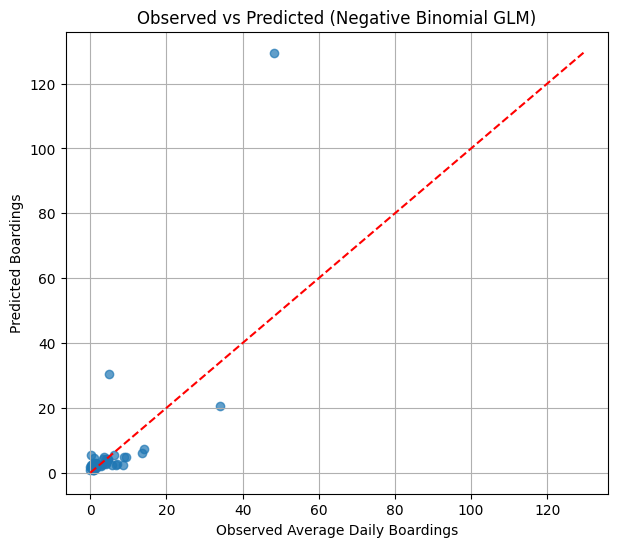

In [13]:
plt.figure(figsize=(7, 6))

plt.scatter(observed, predicted, alpha=0.7)

# perfect fit line
max_val = max(observed.max(), predicted.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--")

plt.xlabel("Observed Average Daily Boardings")
plt.ylabel("Predicted Boardings")
plt.title("Observed vs Predicted (Negative Binomial GLM)")
plt.grid(True)

plt.show()

In [14]:
# Querying stop level data for City of Burbank 

In [15]:
# Burbank, Metrolink, LA Metro Bus and LA metro rail
feed_keys = ["cc6a68a39d22c29b49116584971e69a8", "0f80473907c7613e9fefbb71220e9e56", "8d9623a1823a27925b7e2f00e44fc5bb", "f1ba526e631625c1d6816d055265ed65"]    
feed_keys_str = ", ".join(f"'{k}'" for k in feed_keys)

# Query only those feed_keys
with db_engine.connect() as connection:
    query = f"""
        SELECT 
            feed_key, stop_id, _feed_valid_from, n_hours_in_service, daily_arrivals, arrivals_early_am, arrivals_am_peak, arrivals_midday, 
            arrivals_pm_peak, arrivals_evening, route_id_array, route_type_array, stop_key, tts_stop_name,
            pt_geom, stop_name, location_type, stop_desc, stop_code
        FROM cal-itp-data-infra.mart_gtfs.fct_daily_scheduled_stops
        WHERE service_date = DATE('2025-05-21')
          AND feed_key IN ({feed_keys_str})
    """
    df_agency = pd.read_sql(query, connection)

In [16]:
df = pd.read_csv("burbank_orange_new_stops.csv")
df["stop_dir_key"] = df["stop_name"] + " " + df["direction"]

In [17]:
manual_coords = {
"Hollywood & Jeffries eastbound": (34.18141305368438, -118.34903738211447),
"Hollywood & Victory Bl eastbound": (34.18508535157502, -118.34929119735641),
"Hollywood & Pacific eastbound": (34.18825119276962, -118.34886491064228),
"Hollywood & Valhalla eastbound": (34.19012427165374, -118.34916328937923),
"Hollywood & Thorton eastbound": (34.19656151035557, -118.34876716762236),
"Hollywood & Thorton westbound": (34.195980179882646, -118.34894014653726),
"New BUR terminal eastbound": (34.19359656711031, -118.35357055101639),
"New BUR terminal westbound": (34.19359656711031, -118.35357055101639),
"Winona / Ontario eastbound":  (34.199490557715684, -118.3443711434909),
"Winona / Ontario westbound":  (34.1992091874645, -118.34484346690523),
"Ontario & Thorton eastbound": (34.19593202043652, -118.34444331137956),
"Ontario & Thorton westbound": (34.19541510602419, -118.34460558501739),
"Empire & Ontario eastbound": (34.192108542580186, -118.3443394102755),
"Empire & Buena Vista eastbound": (34.19195822628478, -118.33787457476522),
"Empire & Valpreda eastbound": (34.19194945024493, -118.33285175184913),
"Empire & Valpreda westbound": (34.19179144771815, -118.33244032844016),
"Empire & Grismer eastbound":  (34.19175476406717, -118.32509312643347),
"Empire & Grismer westbound":  (34.19154206721876, -118.3254365921081),
"Amherst Dr / San Fernando eastbound": (34.19012800601128, -118.32086710181368),
"Amherst Dr / San Fernando westbound":  (34.189934438443714, -118.32176619076398),
"Glenoaks & Bethany eastbound":  (34.191647095345786, -118.31754103475315),
"Glenoaks & Bethany westbound":  (34.19168659607283, -118.3180498038794),
"Glenoaks & Fairmount eastbound": (34.18922976877985, -118.31426181767534),
"Glenoaks & Fairmount westbound": (34.18869054389077, -118.3139580922512),
"Glenoaks & Cypress eastbound":  (34.18708018484801, -118.31127153444093),
"Glenoaks & Cypress westbound":  (34.18677382226348, -118.31135025143384),
"Glenoaks & Magnolia eastbound": (34.18566039664216, -118.30935620418528),
"Glenoaks & Magnolia westbound": (34.1853950731641, -118.3094180753144),
"Glenoaks & Olive eastbound": (34.18338784687265, -118.30666291160377),
"Glenoaks & Olive westbound": (34.183750381812565, -118.30682928383196),
"Glenoaks & Verdugo eastbound": (34.1810536128531, -118.30348086446116),
"Glenoaks & Verdugo westbound": (34.18130060913145, -118.30290962506388),
"Glenoaks & Providencia eastbound": (34.17964641863243, -118.30103491619572),
"Glenoaks & Providencia westbound": (34.17927416886304, -118.30121771535951),
"Glenoaks / Alameda eastbound": (34.1769213295822, -118.29787237592716),
"Glenoaks / Alameda westbound": (34.17636895964169, -118.29776384800448),
"Alameda & San Fernando eastbound": (34.174365721132396, -118.29952381900989),
"Alameda & San Fernando westbound": (34.17430732460237, -118.30025580257688),
"Flower & Alameda eastbound": (34.17106795233713, -118.30268518471172),
"Flower & Alameda westbound": (34.17166407022795, -118.3032739880033)
}

In [18]:
df_blue = pd.read_csv("burbank_blue_new_stops.csv")
df_blue["stop_dir_key"] = df_blue ["stop_name"] + " " + df_blue ["direction"]

In [19]:
manual_coords_blue = {
    "Metrolink Station eastside terminal at Front St eastbound": (34.1928297181839, -118.35258351675843),
    "Metrolink Station eastside terminal at Front St westbound": (34.1928297181839, -118.35258351675843),
    "Verdugo & Ikea Way eastbound": (34.17714663954148, -118.3074729252067),
    "Verdugo & Ikea Way westbound": (34.17714663954148, -118.3074729252067),
    "Verdugo & San Fernando eastbound": (34.17878489736103, -118.30541531103879),
    "Verdugo & San Fernando westbound": (34.17851879621711, -118.30606420445262),
    "Glenoaks & Providencia eastbound": (34.17962336385441, -118.30104441612727),
    "Glenoaks & Providencia westbound": (34.17927459077334, -118.30121849159424),
    "Glenoaks / Alameda eastbound": (34.1769213295822, -118.29787237592716),
    "Glenoaks / Alameda westbound": (34.17636895964169, -118.29776384800448),
    "Alameda & San Fernando eastbound": (34.174365721132396, -118.29952381900989),
    "Alameda & San Fernando westbound": (34.17430732460237, -118.30025580257688),
    "Alameda & Lake eastbound": (34.16893683695737, -118.30550179211235),
    "Alameda & Lake westbound": (34.169039897393205, -118.30583857000296),
    "Alameda & Victory eastbound": (34.166763977999786, -118.30764556757374),
    "Alameda & Victory westbound": (34.16653844596177, -118.30776671277157),
    "Alameda & Main eastbound": (34.05882507328523, -118.2372783904341),
    "Alameda & Main westbound": (34.05926978274522, -118.23693452367304),
    "Alameda & Mariposa eastbound": (34.16232050313561, -118.3156158302872),
    "Alameda & Mariposa westbound": (34.16231163244352, -118.3163406121734),
    "Alameda & Reese eastbound": (34.160989586571944, -118.31959642185599),
    "Alameda & Reese westbound": (34.16116470453852, -118.32011647018618),
    "Alameda & Keystone eastbound": (34.15960879667507, -118.32369063587736),
    "Alameda & Keystone westbound": (34.159809285768965, -118.32415899113134),
    "Alameda / Buena Vista eastbound": (34.15830550275982, -118.32847444534262),
    "Alameda / Buena Vista westbound": (34.158061055695796, -118.32827576408872),
    "Buena Vista & Olive eastbound": (34.16071171372398, -118.32948693260309),
    "Buena Vista & Olive westbound": (34.16108254215271, -118.32933331481632),
    "Buena Vista & Verdugo eastbound": (34.16511269756838, -118.33111018379287),
    "Buena Vista & Verdugo westbound": (34.165299805818485, -118.33167323237512),
    "Buena Vista & Clark eastbound": (34.168565005129715, -118.33283674907685),
    "Buena Vista & Clark westbound": (34.16866971383002, -118.33328130798998),
    "Buena Vista & Magnolia eastbound": (34.17195186709472, -118.33452224880612),
    "Buena Vista & Magnolia westbound": (34.17211056589883, -118.33495282578686),
    "Buena Vista & Chandler eastbound": (34.175468005263646, -118.33584132009098),
    "Buena Vista & Chandler westbound": (34.17564123355154, -118.33666600223994),
    "Buena Vista & Burbank eastbound": (34.178999088200214, -118.33829343490339),
    "Buena Vista & Burbank westbound": (34.17876464082475, -118.33765850526345),
    "Buena Vista & Jeffries eastbound": (34.18121005878122, -118.33854591221447),
    "Buena Vista & Jeffries westbound": (34.180900571549294, -118.33814871081255),
    "Buena Vista & Victory eastbound": (34.18449938252548, -118.3380410337855),
    "Buena Vista & Victory westbound": (34.18466457669643, -118.33870399111125),
    "Buena Vista & Pacific eastbound": (34.188461988919315, -118.33840245172041),
    "Buena Vista & Pacific westbound": (34.18806979207031, -118.33819315186547),
    "Buena Vista & Empire eastbound": (34.19198270314381, -118.33837161247952),
    "Buena Vista & Empire westbound": (34.19177371161881, -118.3376321369762),
    "Buena Vista & Thorton eastbound": (34.19573279798583, -118.33806248639054),
    "Buena Vista & Thorton westbound": (34.19545983217905, -118.33766900330374),
    "Buena Vista & Winona eastbound": (34.19971384309687, -118.33802251372927),
    "Buena Vista & Winona westbound": (34.19955262101271, -118.33759639149243),
    "Buena Vista & Tulare eastbound": (34.20288213768749, -118.33803238893368),
    "Buena Vista & Tulare westbound": (34.202779515064044, -118.33757227833074),
    "Glenoaks / Buena Vista eastbound": (34.205108109416635, -118.33787452049432),
    "Glenoaks / Buena Vista westbound": (34.20469583946896, -118.33746105567633),
    "Glenoaks / Cohasset eastbound": (34.206545468267606, -118.34143554899393),
    "Glenoaks / Cohasset westbound": (34.2067229265355, -118.34135508272895),
    "Cohasset & Bloomington eastbound": (34.2065471711793, -118.34523843199325),
    "Cohasset & Bloomington westbound": (34.206793697966674, -118.34551974845968),
    "N San Fernando / Lima / Avon eastbound": (34.19149816424647, -118.34706760310583),
    "N San Fernando / Lima / Avon westbound": (34.192392404649915, -118.3479249843664)
}

In [20]:
from shapely.geometry import Point

In [21]:
def apply_manual_coords(df, manual_coords):
    # filter rows
    df = df[(df['change_type'] != 'no_change') & 
            (df['change_type'] != 'relocating')].copy()
    
    latitudes, longitudes, geoms = [], [], []

    for key in df["stop_dir_key"]:
        coords = manual_coords.get(key)

        if coords:
            lat, lon = coords
            latitudes.append(lat)
            longitudes.append(lon)
            geoms.append(Point(lon, lat))
        else:
            latitudes.append(None)
            longitudes.append(None)
            geoms.append(None)

    df["latitude"] = latitudes
    df["longitude"] = longitudes
    df["pt_geom"] = geoms

    df["stop_id"] = ["new_" + str(i + 1) for i in range(len(df))]

    return df

In [22]:
df = apply_manual_coords(df, manual_coords)
df.head()

,stop_name,direction,change_type,stop_dir_key,latitude,longitude,pt_geom,stop_id
6,Hollywood & Jeffries,eastbound,adding_existing,Hollywood & Jeffries eastbound,34.181413,-118.349037,POINT (-118.34903738211447 34.18141305368438),new_1
8,Hollywood & Victory Bl,eastbound,adding_existing,Hollywood & Victory Bl eastbound,34.185085,-118.349291,POINT (-118.34929119735641 34.18508535157502),new_2
10,Hollywood & Pacific,eastbound,adding_existing,Hollywood & Pacific eastbound,34.188251,-118.348865,POINT (-118.34886491064228 34.18825119276962),new_3
12,Hollywood & Valhalla,eastbound,adding_existing,Hollywood & Valhalla eastbound,34.190124,-118.349163,POINT (-118.34916328937923 34.19012427165374),new_4
14,Hollywood & Thorton,eastbound,adding_existing,Hollywood & Thorton eastbound,34.196562,-118.348767,POINT (-118.34876716762236 34.19656151035557),new_5


In [23]:
df_blue = apply_manual_coords(df_blue, manual_coords_blue)
df_blue.head()

,stop_name,direction,change_type,stop_dir_key,latitude,longitude,pt_geom,stop_id
2,Verdugo & San Fernando,eastbound,adding_existing,Verdugo & San Fernando eastbound,34.178785,-118.305415,POINT (-118.30541531103879 34.17878489736103),new_1
3,Glenoaks & Providencia,eastbound,adding_existing,Glenoaks & Providencia eastbound,34.179623,-118.301044,POINT (-118.30104441612727 34.17962336385441),new_2
4,Glenoaks / Alameda,eastbound,adding_existing,Glenoaks / Alameda eastbound,34.176921,-118.297872,POINT (-118.29787237592716 34.1769213295822),new_3
5,Alameda & San Fernando,eastbound,adding_existing,Alameda & San Fernando eastbound,34.174366,-118.299524,POINT (-118.29952381900989 34.174365721132396),new_4
6,Alameda & Lake,eastbound,adding_existing,Alameda & Lake eastbound,34.168937,-118.305502,POINT (-118.30550179211235 34.16893683695737),new_5


In [24]:
# Convert your stops DataFrame to GeoDataFrame
gdf_orange = gpd.GeoDataFrame(df, geometry='pt_geom', crs="EPSG:4326")
gdf_blue = gpd.GeoDataFrame(df_blue, geometry='pt_geom', crs="EPSG:4326")

# Project to meters for accurate distance buffering (UTM Zone 11N for LA area)
gdf_orange = gdf_orange.to_crs(epsg=32611)
gdf_blue = gdf_blue.to_crs(epsg=32611)

buffer_distance = 804.672  # in meters
gdf_orange['buffer'] = gdf_orange.geometry.buffer(buffer_distance)
gdf_blue['buffer'] = gdf_blue.geometry.buffer(buffer_distance)

In [25]:
# Load the stored ACS dataset from the specified GCS file path.
with fs.open(f"{GCS_FILE_PATH}/census_tracts_data.parquet", "rb") as f:
    tracts_ca_acs = gpd.read_parquet(f)

acs_gdf = tracts_ca_acs.to_crs(gdf_orange.crs)

In [26]:
geometry_intersect_orange = gpd.overlay(acs_gdf, gdf_orange.set_geometry('buffer'), how='intersection')
geometry_intersect_blue = gpd.overlay(acs_gdf, gdf_blue.set_geometry('buffer'), how='intersection')

In [27]:
geometry_intersect_orange['area_2'] = geometry_intersect_orange.geometry.area  # area of overlap
geometry_intersect_orange['area_ratio'] = geometry_intersect_orange['area_2'] / geometry_intersect_orange['area_m2']  # fraction

# Define demographic and socioeconomic columns to be adjusted by area ratio
cols_to_weight = [
    'total_pop', 'workers_with_no_car', 'total_youth', 'total_seniors', 'public_asst_pop', 'inc_total_lowincome']

for col in cols_to_weight:
    geometry_intersect_orange[f'{col}_adj'] = geometry_intersect_orange[col] * geometry_intersect_orange['area_ratio']

In [28]:
geometry_intersect_blue['area_2'] = geometry_intersect_blue.geometry.area  # area of overlap
geometry_intersect_blue['area_ratio'] = geometry_intersect_blue['area_2'] / geometry_intersect_blue['area_m2']  # fraction

# Define demographic and socioeconomic columns to be adjusted by area ratio
cols_to_weight = [
    'total_pop', 'workers_with_no_car', 'total_youth', 'total_seniors', 'public_asst_pop', 'inc_total_lowincome']

for col in cols_to_weight:
    geometry_intersect_blue[f'{col}_adj'] = geometry_intersect_blue[col] * geometry_intersect_blue['area_ratio']

In [29]:
geometry_intersect_orange.head(5)

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,total_pop,poverty_pop,non_us_citizen,male_65_to_66,male_67_to_69,male_70_to_74,male_75_to_79,male_80_to_84,male_85_and_over,female_65_to_66,female_67_to_69,female_70_to_74,female_75_to_79,female_80_to_84,female_85_and_over,male_15_17,male_18_19,male_20,male_21,male_22_24,female_15_17,female_18_19,female_20,female_21,female_22_24,median_household_income,income_less_10000,income_10000_14999,income_15000_24999,income_25000_34999,income_35000_49999,income_50000_64999,income_65000_74999,workers_with_no_car,households_with_no_cars,public_asst_pop,veteran_pop,county_name,inc_extremelylow,inc_verylow,inc_low,inc_total_lowincome,male_seniors,female_seniors,male_youth,female_youth,total_seniors,total_youth,disabled_pop,area_m2,stop_name,direction,change_type,stop_dir_key,latitude,longitude,pt_geom,stop_id,geometry,area_2,area_ratio,total_pop_adj,workers_with_no_car_adj,total_youth_adj,total_seniors_adj,public_asst_pop_adj,inc_total_lowincome_adj
0,06,037,301502,1400000US06037301502,06037301502,3015.02,Census Tract 3015.02,CA,Los Angeles County,California,CT,675937,0,7498,1296,1753,55,48,81,133,49,67,131,160,156,0,80,111,59,153,26,86,307,53,82,0,119,190,80459,997,835,554,626,532,465,260,173,262,877,51,Los Angeles,2386,1158,725,4269,433,638,631,444,1071,1075,1197,676086.191403,Glenoaks & Verdugo,eastbound,adding_existing,Glenoaks & Verdugo eastbound,34.181054,-118.303481,POINT (379878.502 3782998.867),new_31,"POLYGON ((380620.646 3782807.227, 380651.934 3...",32832.425491,0.048562,364.121512,8.401310,52.204671,52.010421,42.589299,207.313248
1,06,037,301502,1400000US06037301502,06037301502,3015.02,Census Tract 3015.02,CA,Los Angeles County,California,CT,675937,0,7498,1296,1753,55,48,81,133,49,67,131,160,156,0,80,111,59,153,26,86,307,53,82,0,119,190,80459,997,835,554,626,532,465,260,173,262,877,51,Los Angeles,2386,1158,725,4269,433,638,631,444,1071,1075,1197,676086.191403,Glenoaks & Verdugo,westbound,new_stop,Glenoaks & Verdugo westbound,34.181301,-118.302910,POINT (379931.498 3783025.584),new_32,"POLYGON ((380620.646 3782807.227, 380685.842 3...",44149.446194,0.065302,489.630689,11.297160,70.199118,69.937912,57.269420,278.772127
2,06,037,301502,1400000US06037301502,06037301502,3015.02,Census Tract 3015.02,CA,Los Angeles County,California,CT,675937,0,7498,1296,1753,55,48,81,133,49,67,131,160,156,0,80,111,59,153,26,86,307,53,82,0,119,190,80459,997,835,554,626,532,465,260,173,262,877,51,Los Angeles,2386,1158,725,4269,433,638,631,444,1071,1075,1197,676086.191403,Glenoaks & Providencia,eastbound,adding_existing,Glenoaks & Providencia eastbound,34.179646,-118.301035,POINT (380101.930 3782839.941),new_33,"POLYGON ((380620.646 3782807.227, 380864.729 3...",130996.792884,0.193758,1452.793986,33.520053,208.289349,207.514318,169.925357,827.150911
3,06,037,301502,1400000US06037301502,06037301502,3015.02,Census Tract 3015.02,CA,Los Angeles County,California,CT,675937,0,7498,1296,1753,55,48,81,133,49,67,131,160,156,0,80,111,59,153,26,86,307,53,82,0,119,190,80459,997,835,554,626,532,465,260,173,262,877,51,Los Angeles,2386,1158,725,4269,433,638,631,444,1071,1075,1197,676086.191403,Glenoaks & Providencia,westbound,adding_existing,Glenoaks & Providencia westbound,34.179274,-118.301218,POINT (380084.556 3782798.877),new_34,"POLYGON ((380620.646 3782807.227, 380860.718 3...",132889.908002,0.196558,1473.789205,34.004472,211.299466,210.513235,172.381053,839.104576
4,06,037,301502,1400000US06037301502,06037301502,3015.02,Census Tract 3015.02,CA,Los Angeles County,California,CT,675937,0,7498,1296,1753,55,48,81,133,49,67,131,160,156,0,80,111,59,153,26,86,307,53,82,0,119,190,80459,997,835,554,626,532,465,260,173,262,877,51,Los Angeles,2386,1158,725,4269,433,638,631,444,1071,1075,1197,676086.191403,Glenoaks / Alameda,eastbound,adding_existing,Glenoaks / Alameda eastbound,34.176921,-118.297872,POINT (380389.550 3782534.037),new_35,"POLYGON ((380620.646 3782807.227, 38

In [30]:
agg_orange = geometry_intersect_orange.groupby(['stop_name', 'direction']).agg({
    'total_pop_adj': 'sum',
    'workers_with_no_car_adj': 'sum',
    'total_seniors_adj': 'sum',
    'total_youth_adj': 'sum',
    'inc_total_lowincome_adj': 'sum'
})
 
gdf_orange = gdf_orange.merge(
    agg_orange,
    on=['stop_name', 'direction'],
    how='left'
)

In [31]:
agg_blue = geometry_intersect_blue.groupby(['stop_name', 'direction']).agg({
    'total_pop_adj': 'sum',
    'workers_with_no_car_adj': 'sum',
    'total_youth_adj': 'sum',
    'total_seniors_adj': 'sum',
    'inc_total_lowincome_adj': 'sum'
})
 
gdf_blue = gdf_blue.merge(
    agg_blue,
    on=['stop_name', 'direction'],
    how='left'
)

In [32]:
# add missing columns with placeholder values for now
gdf_orange['n_arrivals'] = np.nan
gdf_orange['n_routes'] = np.nan
gdf_blue['n_arrivals'] = np.nan
gdf_blue['n_routes'] = np.nan

In [33]:
df_agency.head(5)

,feed_key,stop_id,_feed_valid_from,n_hours_in_service,daily_arrivals,arrivals_early_am,arrivals_am_peak,arrivals_midday,arrivals_pm_peak,arrivals_evening,route_id_array,route_type_array,stop_key,tts_stop_name,pt_geom,stop_name,location_type,stop_desc,stop_code
0,f1ba526e631625c1d6816d055265ed65,80214,2025-05-21 03:01:24.218747+00:00,21,262,3,3,5,5,4,[802],[1],19ece2493f631e3ac0eb036d9a225447,None,POINT(-118.234249 34.056197),Union Station - Metro B & D Lines,0.0,None,80214
1,f1ba526e631625c1d6816d055265ed65,80422,2025-05-21 03:01:24.218747+00:00,23,238,3,3,5,5,4,[801],[0],96a07f9fd5811203743ac58ee5fb78c2,None,POINT(-118.029199 34.14286),Arcadia Station,0.0,None,80422
2,f1ba526e631625c1d6816d055265ed65,80310,2025-05-21 03:01:24.218747+00:00,22,223,3,3,5,5,4,[803],[0],ff2bde5e745f3c0e14b9431c1dbab52f,None,POINT(-118.265217 33.927465),Avalon Station,0.0,None,80310
3,f1ba526e631625c1d6816d055265ed65,80427,2025-05-21 03:01:24.218747+00:00,23,236,3,3,5,5,4,[801],[0],1c194d4ef3de4021dc8988645e46d48a,None,POINT(-117.891636 34.136814),APU / Citrus College Station,0.0,None,80427
4,f1ba526e631625c1d6816d055265ed65,80120,2025-05-21 03:01:24.218747+00:00,21,237,3,3,5,5,4,[801],[0],f0091ce2ee1d481154131e9b1773db75,None,POINT(-118.269333 34.033155),Grand / LATTC Station,0.0,None,80120


In [34]:
df_existing = df_agency.copy()

# convert string representation of list → actual list
df_existing['route_id_array_parsed'] = df_existing['route_id_array'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# compute number of unique routes
df_existing['n_routes'] = df_existing['route_id_array_parsed'].apply(
    lambda x: len(set(x)) if isinstance(x, list) else 0
)

In [35]:
df_existing.head(5)

,feed_key,stop_id,_feed_valid_from,n_hours_in_service,daily_arrivals,arrivals_early_am,arrivals_am_peak,arrivals_midday,arrivals_pm_peak,arrivals_evening,route_id_array,route_type_array,stop_key,tts_stop_name,pt_geom,stop_name,location_type,stop_desc,stop_code,route_id_array_parsed,n_routes
0,f1ba526e631625c1d6816d055265ed65,80214,2025-05-21 03:01:24.218747+00:00,21,262,3,3,5,5,4,[802],[1],19ece2493f631e3ac0eb036d9a225447,None,POINT(-118.234249 34.056197),Union Station - Metro B & D Lines,0.0,None,80214,[802],1
1,f1ba526e631625c1d6816d055265ed65,80422,2025-05-21 03:01:24.218747+00:00,23,238,3,3,5,5,4,[801],[0],96a07f9fd5811203743ac58ee5fb78c2,None,POINT(-118.029199 34.14286),Arcadia Station,0.0,None,80422,[801],1
2,f1ba526e631625c1d6816d055265ed65,80310,2025-05-21 03:01:24.218747+00:00,22,223,3,3,5,5,4,[803],[0],ff2bde5e745f3c0e14b9431c1dbab52f,None,POINT(-118.265217 33.927465),Avalon Station,0.0,None,80310,[803],1
3,f1ba526e631625c1d6816d055265ed65,80427,2025-05-21 03:01:24.218747+00:00,23,236,3,3,5,5,4,[801],[0],1c194d4ef3de4021dc8988645e46d48a,None,POINT(-117.891636 34.136814),APU / Citrus College Station,0.0,None,80427,[801],1
4,f1ba526e631625c1d6816d055265ed65,80120,2025-05-21 03:01:24.218747+00:00,21,237,3,3,5,5,4,[801],[0],f0091ce2ee1d481154131e9b1773db75,None,POINT(-118.269333 34.033155),Grand / LATTC Station,0.0,None,80120,[801],1


In [36]:
from shapely import wkt

# convert WKT string → geometry object
df_existing['geometry'] = df_existing['pt_geom'].apply(wkt.loads)

# extract lon/lat
df_existing['longitude'] = df_existing['geometry'].apply(lambda geom: geom.x)
df_existing['latitude'] = df_existing['geometry'].apply(lambda geom: geom.y)

In [37]:
# drop missing coords just in case
df_existing = df_existing.dropna(subset=['latitude', 'longitude'])
df_new_orange = gdf_orange.dropna(subset=['latitude', 'longitude'])
df_new_blue = gdf_blue.dropna(subset=['latitude', 'longitude'])

In [38]:
from sklearn.neighbors import BallTree
import numpy as np

existing_coords = np.radians(df_existing[['latitude', 'longitude']])
new_coords_orange = np.radians(df_new_orange[['latitude', 'longitude']])
new_coords_blue = np.radians(df_new_blue[['latitude', 'longitude']])

tree = BallTree(existing_coords, metric='haversine')
dist_orange, ind_orange = tree.query(new_coords_orange, k=1)
dist_blue, ind_blue = tree.query(new_coords_blue, k=1)

In [39]:
matched_idx_orange = ind_orange.flatten()

df_new_orange['n_routes_base'] = df_existing.iloc[matched_idx_orange]['n_routes'].values

df_new_orange['nearest_stop_distance_m'] = dist_orange.flatten() * 6371000

df_new_orange['matched_stop_name'] = df_existing.iloc[matched_idx_orange]['stop_name'].values
df_new_orange['matched_stop_id'] = df_existing.iloc[matched_idx_orange]['stop_id'].values
df_new_orange['matched_n_routes'] = df_existing.iloc[matched_idx_orange]['n_routes'].values
df_new_orange['matched_agency_name'] = df_existing.iloc[matched_idx_orange]['feed_key'].values
df_new_orange['n_arrivals_base'] = df_existing.iloc[matched_idx_orange]['daily_arrivals'].values

In [40]:
matched_idx_blue = ind_blue.flatten()
df_new_blue['n_routes_base'] = df_existing.iloc[matched_idx_blue]['n_routes'].values

df_new_blue['nearest_stop_distance_m'] = dist_blue.flatten() * 6371000

df_new_blue['matched_stop_name'] = df_existing.iloc[matched_idx_blue]['stop_name'].values
df_new_blue['matched_stop_id'] = df_existing.iloc[matched_idx_blue]['stop_id'].values
df_new_blue['matched_n_routes'] = df_existing.iloc[matched_idx_blue]['n_routes'].values
df_new_blue['matched_agency_name'] = df_existing.iloc[matched_idx_blue]['feed_key'].values
df_new_blue['n_arrivals_base'] = df_existing.iloc[matched_idx_blue]['daily_arrivals'].values

In [41]:
df_new_orange[['stop_name', 'direction', 'n_arrivals_base', 'matched_stop_name', 'matched_stop_id', 'matched_n_routes',]].sort_values('stop_name').head(10)

,stop_name,direction,n_arrivals_base,matched_stop_name,matched_stop_id,matched_n_routes
37,Alameda & San Fernando,westbound,24,Alameda / San Fernando,18009,1
36,Alameda & San Fernando,eastbound,62,San Fernando / Alameda,5453,1
19,Amherst Dr / San Fernando,westbound,102,San Fernando / Scott,12348,2
18,Amherst Dr / San Fernando,eastbound,96,San Fernando / Amherst,3865,2
13,Empire & Buena Vista,eastbound,96,Empire / Buena Vista,1817,2
17,Empire & Grismer,westbound,102,San Fernando / Grismer,12346,2
16,Empire & Grismer,eastbound,96,San Fernando / Grismer,3868,2
12,Empire & Ontario,eastbound,51,Empire & Ontario,3067457,1
15,Empire & Valpreda,westbound,102,Empire / Valpreda,4635,2
14,Empire & Valpreda,eastbound,96,Empire / Valpreda,1249,2


In [42]:
df_new_blue[['stop_name', 'direction', 'n_arrivals_base', 'matched_stop_name', 'matched_stop_id', 'matched_n_routes',]].sort_values('stop_name').head(12)

,stop_name,direction,n_arrivals_base,matched_stop_name,matched_stop_id,matched_n_routes
8,Alameda & Keystone,eastbound,18,Buena Vista / Alameda,15840,1
35,Alameda & Keystone,westbound,18,Buena Vista / Alameda,15840,1
4,Alameda & Lake,eastbound,23,Alameda / Lake,18119,1
31,Alameda & Lake,westbound,24,Alameda / Lake,18075,1
32,Alameda & Main,westbound,392,Cesar E Chavez / Alameda,9218,4
5,Alameda & Main,eastbound,392,Cesar E Chavez / Alameda,9218,4
6,Alameda & Mariposa,eastbound,24,Victory / Alameda,18076,1
33,Alameda & Mariposa,westbound,18,Olive / Reese,18071,1
7,Alameda & Reese,eastbound,18,Olive / Parish,18070,1
34,Alameda & Reese,westbound,18,Olive / Keystone,18069,1


In [43]:
orange_stops = set(zip(df_new_orange['stop_name'], df_new_orange['direction'], df_new_orange['change_type'], ))
blue_stops = set(zip(df_new_blue['stop_name'], df_new_blue['direction'], df_new_blue['change_type']))

common_stops = orange_stops & blue_stops
list(common_stops)

[('Alameda & San Fernando', 'eastbound', 'adding_existing'),
 ('Glenoaks / Alameda', 'eastbound', 'adding_existing'),
 ('Glenoaks / Alameda', 'westbound', 'adding_existing'),
 ('Glenoaks & Providencia', 'eastbound', 'adding_existing'),
 ('Alameda & San Fernando', 'westbound', 'adding_existing'),
 ('Glenoaks & Providencia', 'westbound', 'adding_existing')]

In [44]:
df_new_orange['source'] = 'orange'
df_new_blue['source'] = 'blue'

In [45]:
df_combined = pd.concat([df_new_orange, df_new_blue], ignore_index=True)
df_combined = df_combined[
    df_combined['change_type'].isin(['new_stop', 'adding_existing'])
].copy()

In [46]:
df_combined['key'] = list(zip(
    df_combined['stop_name'],
    df_combined['direction'],
    df_combined['change_type']
))

df_combined['is_common'] = df_combined['key'].isin(common_stops)

In [47]:
# REMOVE duplicate rows for common stops
df_combined = (
    df_combined
    .sort_values('source')  # keeps orange if duplicate exists
    .drop_duplicates(subset=['key'], keep='first')
)

In [48]:
df_combined['n_routes_base'] = np.where(
    df_combined['change_type'] == 'new_stop',
    0,
    df_combined['n_routes_base']
)

df_combined['n_routes_scn'] = np.where(
    df_combined['change_type'] == 'new_stop',
    1,
    df_combined['n_routes_base'] + 1
)

# instead of forcing 2, increment properly
df_combined.loc[
    df_combined['is_common'] & (df_combined['change_type'] == 'adding_existing'),
    'n_routes_scn'
] += 1


Orange route currently has 51 arrivals; Proposed Blue Routes service :would operate every 20 minutes from 6:00am to 8:00pm, Monday through Friday = 43 arrivals per day.

In [49]:
# apply base reset
is_new = df_combined['change_type'] == 'new_stop'
df_combined.loc[is_new, 'n_arrivals_base'] = 0

# define correct increment
increment = np.where(
    df_combined['is_common'],
    94, 
    df_combined['source'].map({'orange': 51, 'blue': 43})
)

# final calculation 
df_combined['n_arrivals_scn'] = df_combined['n_arrivals_base'] + increment


In [50]:
df_combined.head(3)

,stop_name,direction,change_type,stop_dir_key,latitude,longitude,pt_geom,stop_id,buffer,total_pop_adj,workers_with_no_car_adj,total_seniors_adj,total_youth_adj,inc_total_lowincome_adj,n_arrivals,n_routes,n_routes_base,nearest_stop_distance_m,matched_stop_name,matched_stop_id,matched_n_routes,matched_agency_name,n_arrivals_base,source,key,is_common,n_routes_scn,n_arrivals_scn
45,Alameda & Main,eastbound,new_stop,Alameda & Main eastbound,34.058825,-118.237278,POINT (385815.509 3769368.949),new_6,"POLYGON ((386620.181 3769368.949, 386616.307 3...",14468.600454,387.623467,1715.996254,1559.872917,6804.429329,NaN,NaN,0,94.938646,Cesar E Chavez / Alameda,9218,4,8d9623a1823a27925b7e2f00e44fc5bb,0,blue,"(Alameda & Main, eastbound, new_stop)",False,1,43
66,Verdugo & Ikea Way,westbound,adding_existing,Verdugo & Ikea Way westbound,34.177147,-118.307473,POINT (379505.037 3782570.325),new_27,"POLYGON ((380309.709 3782570.325, 380305.834 3...",10611.944862,306.987385,1827.375548,1019.265555,5811.143720,NaN,NaN,6,9.406820,Verdugo / Ikea,1682,6,8d9623a1823a27925b7e2f00e44fc5bb,217,blue,"(Verdugo & Ikea Way, westbound, adding_existing)",False,7,260
65,Cohasset & Bloomington,eastbound,new_stop,Cohasset & Bloomington eastbound,34.206547,-118.345238,POINT (376067.409 3785875.904),new_26,"POLYGON ((376872.081 3785875.904, 376868.207 3...",4265.089368,41.173862,772.300857,466.130639,2059.705932,NaN,NaN,0,290.160070,Glenoaks / Cabrini,10760,1,8d9623a1823a27925b7e2f00e44fc5bb,0,blue,"(Cohasset & Bloomington, eastbound, new_stop)",False,1,43


In [51]:
df_combined['stop_group'] = df_combined['stop_name']

df_grouped = df_combined.groupby('stop_group').agg({
    'n_arrivals_base': 'mean',
    'n_arrivals_scn': 'mean',
    'n_routes_base': 'mean',
    'n_routes_scn': 'mean',
    'total_pop_adj': 'mean',
    'workers_with_no_car_adj': 'mean',
    'total_youth_adj': 'mean',
    'total_seniors_adj': 'mean',
    'inc_total_lowincome_adj': 'mean',
    'change_type': lambda x: ', '.join(sorted(x.unique()))
}).reset_index()


rail_stops = [
    "Universal Redline Station",
    "NoHo Station",
    "Metrolink Station",
    "Hollywood Burbank Airport RITC",
    "New BUR terminal",
    
]

df_grouped["has_rail_connection_dummy"] = 0

df_grouped.loc[
    df_grouped["stop_group"].isin(rail_stops),
    "has_rail_connection_dummy"
] = 1

In [52]:
X_scn = df_grouped[[
    # 'n_routes_scn',
    # 'n_arrivals_scn',
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
    'has_rail_connection_dummy'
]].copy()



# X_scn = X_scn.rename(columns={
#     'n_routes_scn': 'n_routes',
#     'n_arrivals_scn': 'n_arrivals'
    
# })
# X_scn["log_arrivals"] = np.log(X_scn["n_arrivals"] + 1)

X_scn = sm.add_constant(X_scn)
X_scn = X_scn[model_fe.model.exog_names]
df_grouped['pred_scenario'] = model_fe.predict(X_scn)

In [53]:
X_base = df_grouped[[
    # 'n_routes_base',
    # 'n_arrivals_base',
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
    'has_rail_connection_dummy'
]].fillna(0)

# X_base = X_base.rename(columns={
#     'n_routes_base': 'n_routes',
#     'n_arrivals_base': 'n_arrivals'
# })

# X_base["log_arrivals"] = np.log(X_base["n_arrivals"] + 1)

X_base = sm.add_constant(X_base)
X_base = X_base[model_fe.model.exog_names]
df_grouped['pred_baseline'] = model_fe.predict(X_base)

In [54]:
df_grouped['ridership_change'] = (
    df_grouped['pred_scenario'] - df_grouped['pred_baseline']
)

In [55]:
df_grouped[['stop_group', 'total_pop_adj', 'n_arrivals_base', 'n_arrivals_scn', 'n_routes_base', 'n_routes_scn',
       'workers_with_no_car_adj', 'total_youth_adj', 'total_seniors_adj', 'inc_total_lowincome_adj', 'change_type', 'ridership_change', 'pred_scenario', 'pred_baseline'  ]].head(10)

,stop_group,total_pop_adj,n_arrivals_base,n_arrivals_scn,n_routes_base,n_routes_scn,workers_with_no_car_adj,total_youth_adj,total_seniors_adj,inc_total_lowincome_adj,change_type,ridership_change,pred_scenario,pred_baseline
0,Alameda & Keystone,4293.708795,0.0,43.0,0.0,1.0,33.057828,240.491509,761.825145,1991.379441,new_stop,0.0,1.941187,1.941187
1,Alameda & Lake,9227.693431,23.5,66.5,1.0,2.0,252.765168,949.244058,1084.409976,4642.170179,adding_existing,0.0,7.219622,7.219622
2,Alameda & Main,14507.521342,0.0,43.0,0.0,1.0,388.996496,1558.857385,1725.942594,6817.928354,new_stop,0.0,53.839381,53.839381
3,Alameda & Mariposa,5341.042930,0.0,43.0,0.0,1.0,66.341354,321.765127,913.488790,2552.447381,new_stop,0.0,2.444115,2.444115
4,Alameda & Reese,4670.377970,0.0,43.0,0.0,1.0,22.194411,198.756101,918.907033,2212.922437,new_stop,0.0,1.822577,1.822577
5,Alameda & San Fernando,10714.973649,43.0,137.0,1.0,3.0,238.025200,1168.627935,1697.596217,5877.742833,adding_existing,0.0,5.621587,5.621587
6,Alameda / Buena Vista,4375.653961,20.0,63.0,0.5,1.5,56.714377,395.084899,608.501816,1950.302731,"adding_existing, new_stop",0.0,2.444017,2.444017
7,Amherst Dr / San Fernando,7680.303260,0.0,51.0,0.0,1.0,111.935435,849.488589,1137.810544,3698.842863,new_stop,0.0,4.336360,4.336360
8,Buena Vista & Burbank,6163.106917,8.0,51.0,0.5,1.5,30.013337,561.422704,841.882362,2881.922546,"adding_existing, new_stop",0.0,1.663868,1.663868
9,Buena Vista & Chandler,6280.196957,0.0,43.0,0.0,1.0,23.792660,659.106148,843.444579,2953.610300,new_stop,0.0,1.623382,1.623382


In [58]:
ridership_change = df_burbank["average_daily_boardings"].sum()
print(ridership_change)

225.40909090909093


In [57]:
ridership_change = df_grouped["pred_scenario"].sum()
print(ridership_change)

271.3311085006283


In [60]:
((271.3311085006283-225.40909090909093)/225.40909090909093)*100

20.37274424306962

In [56]:
df_grouped["pred_scenario"].sum() / df_grouped["pred_baseline"].sum()

1.4997349009155052

## Querying Ridership Data for Burbank Bus Service

In [53]:
# Querying NTD Ridership data 
with db_engine.connect() as connection:
    query = """
        SELECT
            agency, ntd_id, reporter_type, report_year, primary_uza_name, unlinked_passenger_trips_upt, agency_voms
        FROM 
            cal-itp-data-infra.mart_ntd.dim_annual_service_agencies
        WHERE 
            state = 'CA' AND report_year = 2024 
            AND agency IN (
                'City of Burbank',
                'Southern California Regional Rail Authority, dba: Metrolink',
                'Los Angeles County Metropolitan Transportation Authority , dba: Metro'
            )
    """
    ridership_data= pd.read_sql(query, connection)

In [54]:
ridership_data.head(5)

,agency,ntd_id,reporter_type,report_year,primary_uza_name,unlinked_passenger_trips_upt,agency_voms
0,Los Angeles County Metropolitan Transportation...,90154,Full Reporter,2024,"Los Angeles--Long Beach--Anaheim, CA",302611788.0,2722.0
1,"Southern California Regional Rail Authority, d...",90151,Full Reporter,2024,"Los Angeles--Long Beach--Anaheim, CA",4321271.0,195.0
2,City of Burbank,90256,Reduced Reporter,2024,"Los Angeles--Long Beach--Anaheim, CA",211543.0,17.0


In [55]:
summed_ridership = ridership_data['unlinked_passenger_trips_upt'].sum()
average_daily_ridership = summed_ridership / 365
average_daily_ridership

841492.0602739726

In [56]:
# City of Burbank UPT
burbank_upt = ridership_data.loc[
    ridership_data["agency"] == "City of Burbank",
    "unlinked_passenger_trips_upt"
].iloc[0]

# City of Burbank average daily ridership
burbank_avg_daily = burbank_upt / 365

# percentage share of daily ridership
burbank_share_daily_pct = (burbank_avg_daily / average_daily_ridership) * 100

burbank_share_daily_pct

0.06887407384747071

In [57]:
burbank_avg_daily

579.5698630136986